In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("imranzama444n/brainmerged")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/imranzama444n/brainmerged


In [2]:
import os
from collections import defaultdict

DATASET_PATH = "/kaggle/input/datasets/imranzama444n/brainmerged"

IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

total_images = 0
class_counts = defaultdict(int)

print("Checking path:", DATASET_PATH)
print("Path exists:", os.path.exists(DATASET_PATH))

for root, dirs, files in os.walk(DATASET_PATH):
    image_files = [f for f in files if f.lower().endswith(IMG_EXTS)]
    
    if image_files:
        class_name = os.path.basename(root)
        count = len(image_files)
        class_counts[class_name] += count
        total_images += count

print("\nClass-wise image count:")
for cls, count in sorted(class_counts.items()):
    print(f"{cls}: {count}")

print("\nTotal images:", total_images)

Checking path: /kaggle/input/datasets/imranzama444n/brainmerged
Path exists: True

Class-wise image count:
glioma: 1621
healthy: 2000
meningioma: 1645
pituitary: 1757

Total images: 7023



Processing class: glioma (1621 images)


glioma Progress: 100%|█████████████████████████████████████████| 1621/1621 [00:15<00:00, 105.46it/s]



Processing class: healthy (2000 images)


healthy Progress: 100%|████████████████████████████████████████| 2000/2000 [00:16<00:00, 122.20it/s]



Processing class: meningioma (1645 images)


meningioma Progress: 100%|█████████████████████████████████████| 1645/1645 [00:14<00:00, 116.99it/s]



Processing class: pituitary (1757 images)


pituitary Progress: 100%|██████████████████████████████████████| 1757/1757 [00:16<00:00, 106.22it/s]


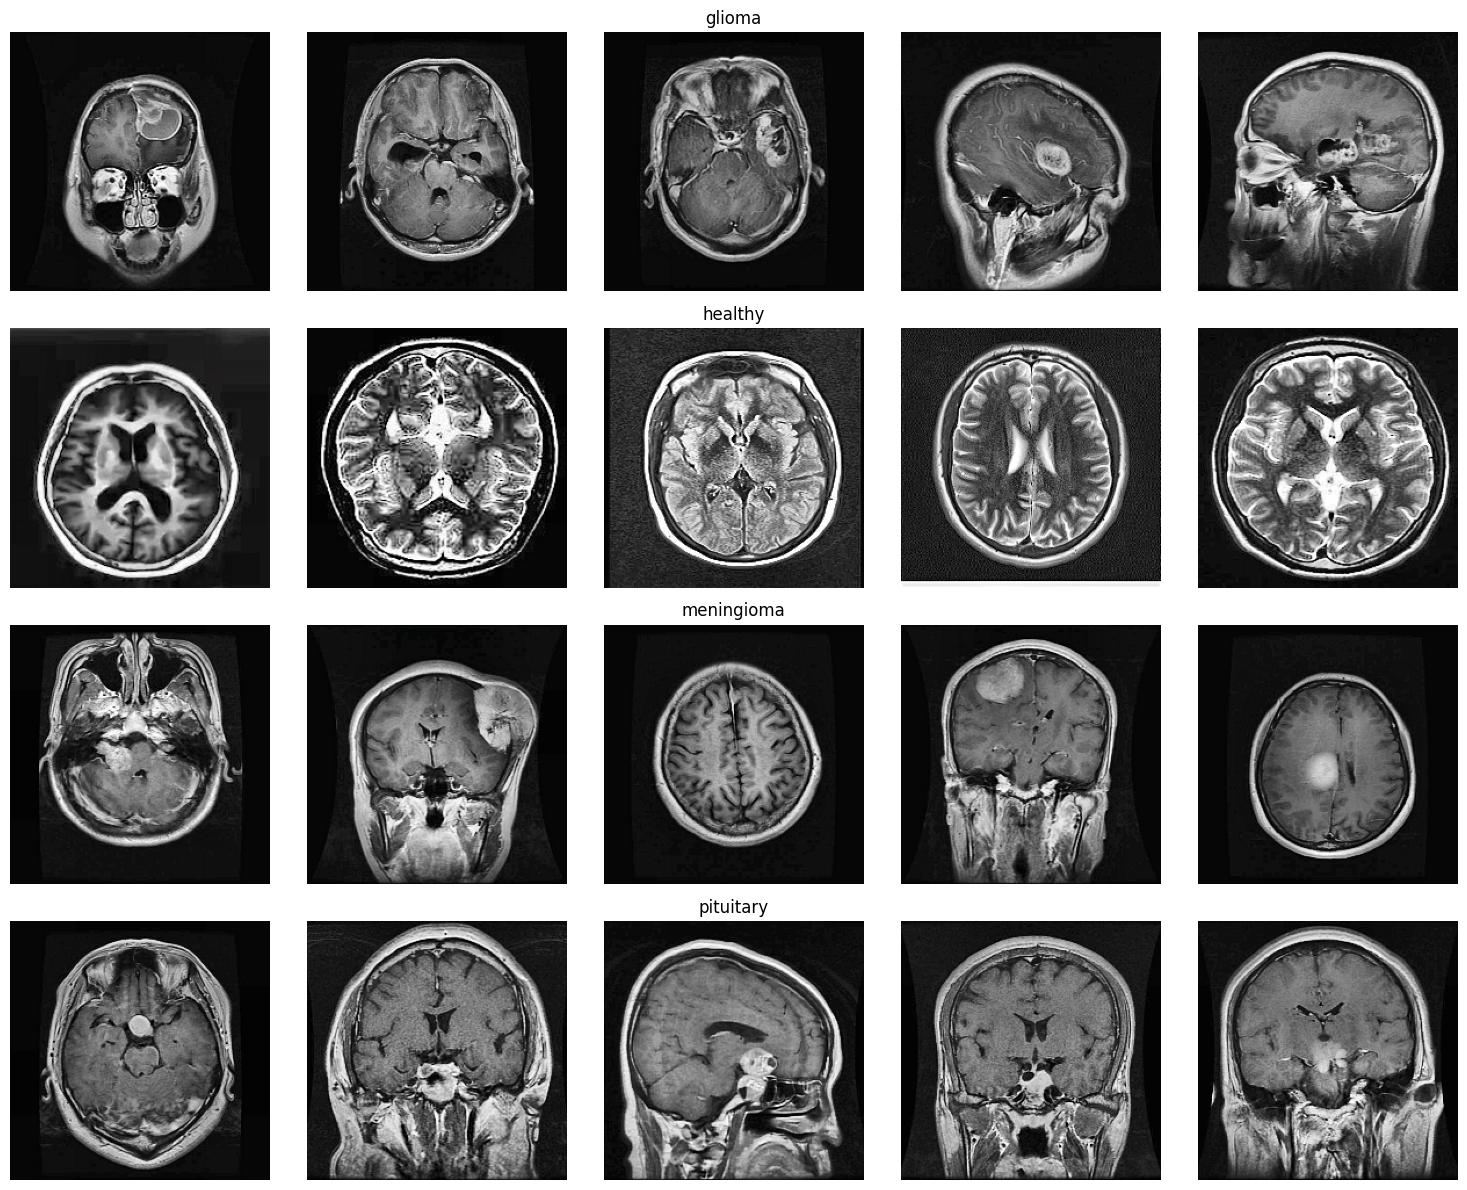


✅ Preprocessed images saved in: /kaggle/working/preprocessed_dataset


In [3]:
import os
import cv2
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm import tqdm

# Paths
input_dir = "/kaggle/input/datasets/imranzama444n/brainmerged"
output_dir = "/kaggle/working/preprocessed_dataset"
os.makedirs(output_dir, exist_ok=True)

img_size = (224, 224)
num_samples = 5
device = "cuda" if torch.cuda.is_available() else "cpu"

# Gaussian filter (GPU)
def gaussian_filter_gpu(img_tensor, kernel_size=5, sigma=1.0):
    C,H,W = img_tensor.shape
    x = torch.arange(kernel_size, dtype=torch.float32, device=img_tensor.device) - kernel_size//2
    gauss = torch.exp(-(x**2)/(2*sigma**2))
    gauss = gauss / gauss.sum()
    gauss_2d = gauss[:, None] @ gauss[None, :]
    gauss_2d = gauss_2d.expand(C,1,kernel_size,kernel_size)
    img_tensor = img_tensor.unsqueeze(0)
    img_filtered = F.conv2d(img_tensor, gauss_2d, padding=kernel_size//2, groups=C)
    return img_filtered[0]

# Classes
classes = sorted([d for d in os.listdir(input_dir) if os.path.isdir(os.path.join(input_dir, d))])

fig, axes = plt.subplots(len(classes), num_samples, figsize=(15,3*len(classes)))

for i, cls in enumerate(classes):
    cls_path = os.path.join(input_dir, cls)
    save_cls_path = os.path.join(output_dir, cls)
    os.makedirs(save_cls_path, exist_ok=True)

    files = [f for f in os.listdir(cls_path) if f.lower().endswith((".jpg",".png",".jpeg"))]
    sample_files = random.sample(files, min(num_samples,len(files)))

    print(f"\nProcessing class: {cls} ({len(files)} images)")
    for file in tqdm(files, desc=f"{cls} Progress", ncols=100):
        img_path = os.path.join(cls_path, file)
        img = cv2.imread(img_path)
        if img is None:
            continue

        # 1️⃣ Resize
        img_resized = cv2.resize(img, img_size)

        # 2️⃣ CLAHE on L channel
        lab = cv2.cvtColor(img_resized, cv2.COLOR_BGR2LAB)
        l,a,b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4,4))
        l_clahe = clahe.apply(l)
        lab_clahe = cv2.merge((l_clahe,a,b))
        img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

        # 3️⃣ Convert to tensor [C,H,W] in 0-1
        img_tensor = torch.from_numpy(img_clahe.transpose(2,0,1)).float().to(device)/255.0

        # 4️⃣ Gaussian smoothing
        img_blur = gaussian_filter_gpu(img_tensor, kernel_size=5, sigma=1.0)

        # 5️⃣ Sharpening (Unsharp mask)
        img_sharp = torch.clamp(1.5*img_tensor - 0.5*img_blur,0,1)

        # 6️⃣ Contrast Stretching
        min_val = img_sharp.min()
        max_val = img_sharp.max()
        img_contrast = (img_sharp - min_val)/(max_val - min_val + 1e-8)  # avoid div by zero

        # 7️⃣ Save image back to CPU
        img_final = (img_contrast.cpu().numpy()*255).astype(np.uint8).transpose(1,2,0)
        cv2.imwrite(os.path.join(save_cls_path, file), img_final)

        # Plot sample images
        if file in sample_files:
            ax = axes[i,sample_files.index(file)]
            ax.imshow(cv2.cvtColor(img_final, cv2.COLOR_BGR2RGB))
            ax.axis("off")
            if sample_files.index(file) == num_samples//2:
                ax.set_title(cls, fontsize=12)

plt.tight_layout()
plt.show()
print("\n✅ Preprocessed images saved in:", output_dir)


In [4]:
import os
import shutil
import random

# Preprocessed dataset path
preprocessed_dir = "/kaggle/working/preprocessed_dataset"

# Split paths
split_base = "/kaggle/working/brain_split"
train_dir = os.path.join(split_base, "train")
val_dir   = os.path.join(split_base, "val")
test_dir  = os.path.join(split_base, "test")


for d in [train_dir, val_dir, test_dir]:
    os.makedirs(d, exist_ok=True)

# Split ratios
train_ratio = 0.80
val_ratio = 0.10
test_ratio = 0.10

classes = sorted(os.listdir(preprocessed_dir))

for cls in classes:
    cls_path = os.path.join(preprocessed_dir, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    random.shuffle(files)

    n_total = len(files)
    n_train = int(train_ratio * n_total)
    n_val = int(val_ratio * n_total)
    n_test = n_total - n_train - n_val

    splits = {
        train_dir: files[:n_train],
        val_dir: files[n_train:n_train+n_val],
        test_dir: files[n_train+n_val:]
    }

    for split_folder, split_files in splits.items():
        cls_split_path = os.path.join(split_folder, cls)
        os.makedirs(cls_split_path, exist_ok=True)
        for f in split_files:
            shutil.copy(os.path.join(cls_path, f), os.path.join(cls_split_path, f))

print("✅ Dataset split into 80-10-10 and saved in:", split_base)


✅ Dataset split into 80-10-10 and saved in: /kaggle/working/brain_split


In [5]:
import os
import cv2
import numpy as np
import random

train_dir = "/kaggle/working/brain_split/train"
aug_train_dir = "/kaggle/working/brain_train_aug"
os.makedirs(aug_train_dir, exist_ok=True)

# =========================
# Augmentation functions
# =========================
def random_flip(img):
    flip_code = random.choice([-1, 0, 1])
    return cv2.flip(img, flip_code)

def random_rotate(img):
    angle = random.uniform(-25, 25)
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 2)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

def random_zoom(img):
    zoom_factor = random.uniform(0.8, 1.2)
    h, w = img.shape[:2]
    new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)
    img_resized = cv2.resize(img, (new_w, new_h))
    if zoom_factor < 1:
        pad_h = (h - new_h) // 2
        pad_w = (w - new_w) // 2
        img_padded = cv2.copyMakeBorder(
            img_resized, pad_h, h - new_h - pad_h,
            pad_w, w - new_w - pad_w, cv2.BORDER_REFLECT
        )
        return img_padded
    else:
        start_h = (new_h - h) // 2
        start_w = (new_w - w) // 2
        return img_resized[start_h:start_h + h, start_w:start_w + w]

def random_brightness(img):
    factor = random.uniform(0.7, 1.3)
    img = img.astype(np.float32) * factor
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

augmentations = [random_flip, random_rotate, random_zoom, random_brightness]

# =========================
# Apply augmentations (2 augmentations per image)
# =========================
classes = sorted(os.listdir(train_dir))
for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    save_cls_path = os.path.join(aug_train_dir, cls)
    os.makedirs(save_cls_path, exist_ok=True)

    for file in os.listdir(cls_path):
        if not file.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
        img_path = os.path.join(cls_path, file)
        img = cv2.imread(img_path)

        # Save original image
        cv2.imwrite(os.path.join(save_cls_path, file), img)

        # Apply TWO random augmentations
        aug_funcs = random.sample(augmentations, 2)
        aug_img = img.copy()
        
        for i, aug_func in enumerate(aug_funcs):
            aug_img = aug_func(aug_img)  
            filename, ext = os.path.splitext(file)
            aug_name = f"{filename}_aug{i+1}{ext}" 
            cv2.imwrite(os.path.join(save_cls_path, aug_name), aug_img)

# =========================
# Print image count per class
# =========================
print("\n📊 Image count per class after augmentation:")
for cls in classes:
    cls_path = os.path.join(aug_train_dir, cls)
    count = len([f for f in os.listdir(cls_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
    print(f"{cls}: {count} images")

print(f"\n✅ All train images and two augmented versions per image saved in: {aug_train_dir}")



📊 Image count per class after augmentation:
glioma: 3888 images
healthy: 4800 images
meningioma: 3948 images
pituitary: 4215 images

✅ All train images and two augmented versions per image saved in: /kaggle/working/brain_train_aug


In [6]:
# ============================================================
# Brain MRI Tumor Classification - ResNet101 + SE
# 5-Fold Stratified Cross-Validation

# ============================================================

import os
import copy
import random
import warnings
import numpy as np
import pandas as pd

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models

from sklearn.model_selection import StratifiedKFold
from scipy.stats import chi2_contingency, kruskal

warnings.filterwarnings("ignore")


# ============================================================
# 1. Configuration
# ============================================================

DATA_DIR = "/kaggle/working/brain_train_aug"  

BATCH_SIZE = 32
IMG_SIZE = 224
EPOCHS = 50
PATIENCE = 5
LR = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT_RATE = 0.3

N_SPLITS = 5
RANDOM_STATE = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")


# ============================================================
# 2. Reproducibility
# ============================================================

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


seed_everything(RANDOM_STATE)


# ============================================================
# 3. Transforms
# ============================================================

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])


# ============================================================
# 4. Custom Dataset for Fold-wise Transform
# ============================================================

class FoldDataset(Dataset):
    def __init__(self, samples, indices, transform=None):
        self.samples = [samples[i] for i in indices]
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label


# ============================================================
# 5. Model: ResNet101 + SE
# ============================================================

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()

        hidden = max(channels // reduction, 1)

        self.avg_pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(
            nn.Linear(channels, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y


class ResNet101_SE(nn.Module):
    def __init__(self, num_classes, dropout=DROPOUT_RATE):
        super().__init__()

        try:
            weights = models.ResNet101_Weights.IMAGENET1K_V1
            base = models.resnet101(weights=weights, progress=False)
        except Exception:
            base = models.resnet101(weights=None, progress=False)

        self.features = nn.Sequential(*list(base.children())[:-2])

        self.se = SEBlock(channels=2048, reduction=16)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(2048, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.se(x)
        x = self.classifier(x)
        return x


# ============================================================
# 6. Training Function
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()

    total_loss = 0.0
    total_count = 0

    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * imgs.size(0)
        total_count += imgs.size(0)

    return total_loss / total_count


# ============================================================
# 7. Validation Function
# ============================================================

@torch.no_grad()
def validate_model(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    total_count = 0

    all_labels = []
    all_preds = []

    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        preds = torch.argmax(outputs, dim=1)

        total_loss += loss.item() * imgs.size(0)
        total_count += imgs.size(0)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

    val_loss = total_loss / total_count

    return val_loss, np.array(all_labels), np.array(all_preds)


# ============================================================
# 8. Load Dataset
# ============================================================

base_dataset = datasets.ImageFolder(DATA_DIR)

samples = base_dataset.samples
targets = np.array(base_dataset.targets)
class_names = base_dataset.classes
num_classes = len(class_names)

print(f"Classes: {class_names}")
print(f"Number of classes: {num_classes}")
print(f"Total images: {len(samples)}")


# ============================================================
# 9. Five-Fold Cross Validation
# ============================================================

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

all_fold_records = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(np.zeros(len(targets)), targets),
    start=1
):
    print(f"\n================ Fold {fold}/{N_SPLITS} ================")

    train_ds = FoldDataset(
        samples=samples,
        indices=train_idx,
        transform=train_transform
    )

    val_ds = FoldDataset(
        samples=samples,
        indices=val_idx,
        transform=val_transform
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    model = ResNet101_SE(
        num_classes=num_classes,
        dropout=DROPOUT_RATE
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=2,
        factor=0.5
    )

    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    for epoch in range(1, EPOCHS + 1):

        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            scaler
        )

        val_loss, y_true, y_pred = validate_model(
            model,
            val_loader,
            criterion
        )

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            break

    model.load_state_dict(best_state)

    final_val_loss, y_true, y_pred = validate_model(
        model,
        val_loader,
        criterion
    )

    correct_values = (y_true == y_pred).astype(int)

    for c in correct_values:
        all_fold_records.append({
            "Fold": fold,
            "Correct": int(c)
        })

    print(f"Fold {fold} completed.")

    del model
    torch.cuda.empty_cache()


# ============================================================
# 10. Statistical Significance Among Folds
# ============================================================

results_df = pd.DataFrame(all_fold_records)

contingency_table = pd.crosstab(
    results_df["Fold"],
    results_df["Correct"]
)

contingency_table = contingency_table.reindex(
    index=range(1, N_SPLITS + 1),
    columns=[0, 1],
    fill_value=0
)

print("\n================ Statistical Significance Among Folds ================")

if results_df["Correct"].nunique() < 2:
    print("All fold predictions have identical correctness values.")
    print("Statistical significance test cannot be computed because there is no variability.")
else:
    chi2_stat, chi2_p, chi2_dof, chi2_expected = chi2_contingency(
        contingency_table.values
    )

    fold_groups = [
        results_df[results_df["Fold"] == fold]["Correct"].values
        for fold in range(1, N_SPLITS + 1)
    ]

    try:
        kruskal_stat, kruskal_p = kruskal(*fold_groups)
    except ValueError:
        kruskal_stat, kruskal_p = np.nan, np.nan

    print(f"Chi-square test: statistic = {chi2_stat:.4f}, df = {chi2_dof}, p-value = {chi2_p:.6f}")

    if not np.isnan(kruskal_p):
        print(f"Kruskal-Wallis test: statistic = {kruskal_stat:.4f}, p-value = {kruskal_p:.6f}")
    else:
        print("Kruskal-Wallis test could not be computed due to identical values.")

    print("\n================ Interpretation ================")

    if chi2_p < 0.05:
        print("Result: Statistically significant difference exists among the five folds.")
    else:
        print("Result: No statistically significant difference exists among the five folds.")

Using device: cuda
Classes: ['glioma', 'healthy', 'meningioma', 'pituitary']
Number of classes: 4
Total images: 7023

================ Fold 1/5 ================
Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth
Fold 1 completed.

================ Fold 2/5 ================
Fold 2 completed.

================ Fold 3/5 ================
Fold 3 completed.

================ Fold 4/5 ================
Fold 4 completed.

================ Fold 5/5 ================
Fold 5 completed.

================ Statistical Significance Among Folds ================
Chi-square test: statistic = 1.9355, df = 4, p-value = 0.747614
Kruskal-Wallis test: statistic = 1.9353, p-value = 0.747664

================ Interpretation ================
Result: No statistically significant difference exists among the five folds.


In [7]:
# ============================================================
# Brain MRI Tumor Classification - ResNet101 + SE
# 5-Fold Stratified Cross-Validation
# Statistical Significance Among Folds
# Chi-square + Wilcoxon Rank-Sum Test

# ============================================================

import os
import copy
import random
import warnings
import itertools
import numpy as np
import pandas as pd

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models

from sklearn.model_selection import StratifiedKFold
from scipy.stats import chi2_contingency, mannwhitneyu

warnings.filterwarnings("ignore")


# ============================================================
# 1. Configuration
# ============================================================

DATA_DIR = "/kaggle/working/preprocessed_dataset"

BATCH_SIZE = 32
IMG_SIZE = 224
EPOCHS = 50
PATIENCE = 5
LR = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT_RATE = 0.3

N_SPLITS = 5
RANDOM_STATE = 42
ALPHA = 0.05

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")


# ============================================================
# 2. Reproducibility
# ============================================================

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


seed_everything(RANDOM_STATE)


# ============================================================
# 3. Transforms
# ============================================================

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])


# ============================================================
# 4. Custom Dataset for Fold-wise Transform
# ============================================================

class FoldDataset(Dataset):
    def __init__(self, samples, indices, transform=None):
        self.samples = [samples[i] for i in indices]
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label


# ============================================================
# 5. Model: ResNet101 + SE
# ============================================================

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()

        hidden = max(channels // reduction, 1)

        self.avg_pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(
            nn.Linear(channels, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y


class ResNet101_SE(nn.Module):
    def __init__(self, num_classes, dropout=DROPOUT_RATE):
        super().__init__()

        try:
            weights = models.ResNet101_Weights.IMAGENET1K_V1
            base = models.resnet101(weights=weights, progress=False)
        except Exception:
            base = models.resnet101(weights=None, progress=False)

        self.features = nn.Sequential(*list(base.children())[:-2])

        self.se = SEBlock(channels=2048, reduction=16)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(2048, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.se(x)
        x = self.classifier(x)
        return x


# ============================================================
# 6. Training Function
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()

    total_loss = 0.0
    total_count = 0

    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * imgs.size(0)
        total_count += imgs.size(0)

    return total_loss / total_count


# ============================================================
# 7. Validation Function
# ============================================================

@torch.no_grad()
def validate_model(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    total_count = 0

    all_labels = []
    all_preds = []

    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        preds = torch.argmax(outputs, dim=1)

        total_loss += loss.item() * imgs.size(0)
        total_count += imgs.size(0)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

    val_loss = total_loss / total_count

    return val_loss, np.array(all_labels), np.array(all_preds)


# ============================================================
# 8. Load Dataset
# ============================================================

base_dataset = datasets.ImageFolder(DATA_DIR)

samples = base_dataset.samples
targets = np.array(base_dataset.targets)
class_names = base_dataset.classes
num_classes = len(class_names)

print(f"Classes: {class_names}")
print(f"Number of classes: {num_classes}")
print(f"Total images: {len(samples)}")


# ============================================================
# 9. Five-Fold Cross Validation
# ============================================================

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

all_fold_records = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(np.zeros(len(targets)), targets),
    start=1
):
    print(f"\n================ Fold {fold}/{N_SPLITS} ================")

    train_ds = FoldDataset(
        samples=samples,
        indices=train_idx,
        transform=train_transform
    )

    val_ds = FoldDataset(
        samples=samples,
        indices=val_idx,
        transform=val_transform
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    model = ResNet101_SE(
        num_classes=num_classes,
        dropout=DROPOUT_RATE
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=2,
        factor=0.5
    )

    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    for epoch in range(1, EPOCHS + 1):

        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            scaler
        )

        val_loss, y_true, y_pred = validate_model(
            model,
            val_loader,
            criterion
        )

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            break

    model.load_state_dict(best_state)

    final_val_loss, y_true, y_pred = validate_model(
        model,
        val_loader,
        criterion
    )

    correct_values = (y_true == y_pred).astype(int)

    for c in correct_values:
        all_fold_records.append({
            "Fold": fold,
            "Correct": int(c)
        })

    print(f"Fold {fold} completed.")

    del model
    torch.cuda.empty_cache()


# ============================================================
# 10. Statistical Significance Among Folds
# ============================================================

results_df = pd.DataFrame(all_fold_records)

contingency_table = pd.crosstab(
    results_df["Fold"],
    results_df["Correct"]
)

contingency_table = contingency_table.reindex(
    index=range(1, N_SPLITS + 1),
    columns=[0, 1],
    fill_value=0
)

print("\n================ Statistical Significance Among Folds ================")

print("\nContingency Table")
print("Rows = Folds, Columns = Incorrect(0), Correct(1)")
print(contingency_table)


# ============================================================
# 10.1 Chi-square Test
# ============================================================

if results_df["Correct"].nunique() < 2:
    print("\nAll predictions have identical correctness values.")
    print("Chi-square test cannot be computed because there is no variability.")
else:
    chi2_stat, chi2_p, chi2_dof, chi2_expected = chi2_contingency(
        contingency_table.values
    )

    print("\n================ Chi-square Test ================")
    print(f"Statistic: {chi2_stat:.4f}")
    print(f"Degrees of freedom: {chi2_dof}")
    print(f"p-value: {chi2_p:.6f}")

    if chi2_p < ALPHA:
        print("Decision: Statistically significant difference exists among the five folds.")
    else:
        print("Decision: No statistically significant difference exists among the five folds.")


# ============================================================
# 10.2 Pairwise Wilcoxon Rank-Sum Test
# ============================================================
# This is also known as Mann-Whitney U test.
# It is used here because fold samples are independent, not paired.
# Bonferroni correction is applied for multiple pairwise comparisons.

print("\n================ Pairwise Wilcoxon Rank-Sum Tests ================")

fold_groups = {
    fold: results_df[results_df["Fold"] == fold]["Correct"].values
    for fold in range(1, N_SPLITS + 1)
}

pairwise_results = []
pairs = list(itertools.combinations(range(1, N_SPLITS + 1), 2))
num_comparisons = len(pairs)

for fold_a, fold_b in pairs:
    group_a = fold_groups[fold_a]
    group_b = fold_groups[fold_b]

    if len(np.unique(np.concatenate([group_a, group_b]))) < 2:
        u_stat = np.nan
        raw_p = np.nan
        corrected_p = np.nan
        decision = "Not computable"
    else:
        u_stat, raw_p = mannwhitneyu(
            group_a,
            group_b,
            alternative="two-sided",
            method="asymptotic"
        )

        corrected_p = min(raw_p * num_comparisons, 1.0)

        if corrected_p < ALPHA:
            decision = "Significant"
        else:
            decision = "Not significant"

    pairwise_results.append({
        "Fold Pair": f"Fold {fold_a} vs Fold {fold_b}",
        "U-statistic": u_stat,
        "Raw p-value": raw_p,
        "Bonferroni p-value": corrected_p,
        "Decision": decision
    })

pairwise_df = pd.DataFrame(pairwise_results)

print(pairwise_df.to_string(index=False))


# ============================================================
# 11. Final Interpretation
# ============================================================

print("\n================ Final Interpretation ================")

if results_df["Correct"].nunique() < 2:
    print("The statistical tests could not be meaningfully interpreted because all predictions had identical correctness values.")
else:
    if chi2_p >= ALPHA:
        print("Global result: No statistically significant difference exists among the five folds based on the Chi-square test.")
    else:
        print("Global result: A statistically significant difference exists among the five folds based on the Chi-square test.")

    significant_pairs = pairwise_df[pairwise_df["Decision"] == "Significant"]

    if len(significant_pairs) == 0:
        print("Pairwise result: No fold pair showed a statistically significant difference after Bonferroni correction.")
    else:
        print("Pairwise result: Some fold pairs showed statistically significant differences after Bonferroni correction.")
        print(significant_pairs.to_string(index=False))

Using device: cuda
Classes: ['glioma', 'healthy', 'meningioma', 'pituitary']
Number of classes: 4
Total images: 7023

================ Fold 1/5 ================
Fold 1 completed.

================ Fold 2/5 ================
Fold 2 completed.

================ Fold 3/5 ================
Fold 3 completed.

================ Fold 4/5 ================
Fold 4 completed.

================ Fold 5/5 ================
Fold 5 completed.

================ Statistical Significance Among Folds ================

Contingency Table
Rows = Folds, Columns = Incorrect(0), Correct(1)
Correct   0     1
Fold             
1        11  1394
2         8  1397
3         8  1397
4         9  1395
5        13  1391

================ Chi-square Test ================
Statistic: 1.9355
Degrees of freedom: 4
p-value: 0.747614
Decision: No statistically significant difference exists among the five folds.

================ Pairwise Wilcoxon Rank-Sum Tests ================
       Fold Pair  U-statistic  Raw p-value  Bonferr